In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import supervision as sv

def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def auto_detect_white_lines_corners(frame_bgr):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    lower_white = np.array([0, 0, 180])
    upper_white = np.array([180, 50, 255])
    mask = cv2.inRange(hsv, lower_white, upper_white)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    mask = cv2.dilate(mask, kernel, iterations=3)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)
    
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
        
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    for cnt in contours[:3]:
        hull = cv2.convexHull(cnt)
        epsilon = 0.02 * cv2.arcLength(hull, True)
        approx = cv2.approxPolyDP(hull, epsilon, True)
        
        if len(approx) == 4 and cv2.contourArea(approx) > 50000:
            pts = approx.reshape(4, 2)
            return order_points(pts)
            
    return None

In [3]:
# Cargar imagen de prueba
image_bgr = cv2.imread("assets/Frames_roboflow/IMG_9933_frame_0000.jpg")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

print(f"Imagen original: {image_bgr.shape[1]}×{image_bgr.shape[0]} px")

# Detección de puntos
detected_points = auto_detect_white_lines_corners(image_bgr)

if detected_points is not None:
    print("Esquinas detectadas automáticamente.")
    SOURCE_POINTS = detected_points
else:
    print("Usando puntos fijos de respaldo.")
    # Esquinas manuales de respaldo
    SOURCE_POINTS = np.float32([
        [ 20,  165],   # 1 -> esquina superior-izquierda
        [590,   40],   # 2 -> esquina superior-derecha
        [592, 1052],   # 3 -> esquina inferior-derecha
        [ 15,  985],   # 4 -> esquina inferior-izquierda
    ])

Imagen original: 1080×1920 px
Esquinas detectadas automáticamente.


Matriz H 


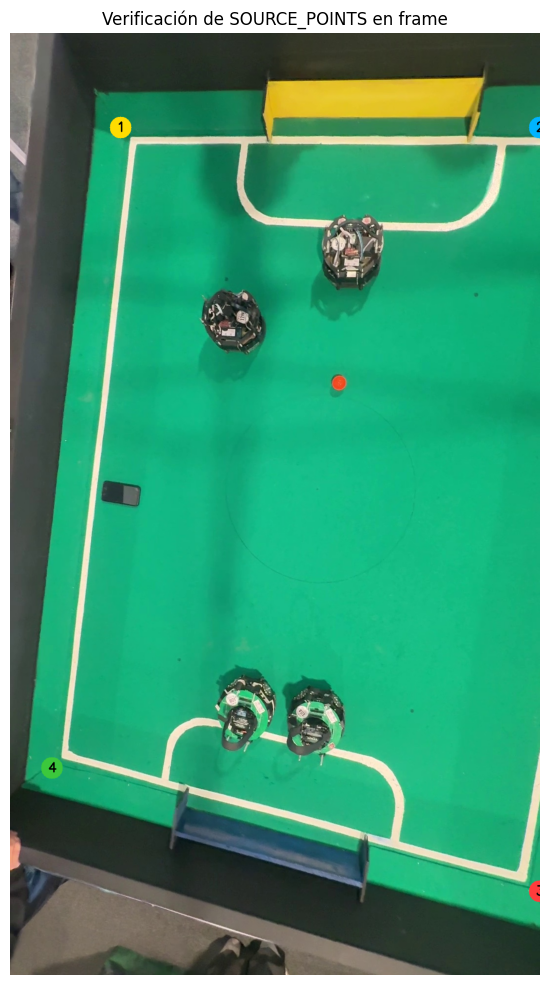

In [5]:
# Campo canónico objetivo
CAMPO_W, CAMPO_H = 364, 486
ESCALA_PX_CM = 2.0  # 1 cm real = 2 px en el campo canónico

TARGET_POINTS = np.float32([
    [       0,        0],   # 1 -> TL canónico
    [CAMPO_W,         0],   # 2 -> TR canónico
    [CAMPO_W, CAMPO_H  ],   # 3 -> BR canónico
    [       0, CAMPO_H ],   # 4 -> BL canónico
])

SOURCE_POINTS = np.array(SOURCE_POINTS, dtype=np.float32).reshape(4, 2)
TARGET_POINTS = np.array(TARGET_POINTS, dtype=np.float32).reshape(4, 2)

H = cv2.getPerspectiveTransform(SOURCE_POINTS, TARGET_POINTS)
print("Matriz H ")

PUNTO_COLORS = [(255, 220, 0), (0, 180, 255), (255, 60, 60), (60, 200, 60)]
vis = image_rgb.copy()
for idx, (pt, color) in enumerate(zip(SOURCE_POINTS, PUNTO_COLORS)):
    x, y = int(pt[0]), int(pt[1])
    cv2.circle(vis, (x, y), 22, color, -1)
    cv2.putText(vis, str(idx + 1), (x - 8, y + 8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 0), 2)

plt.figure(figsize=(5.6, 10))
plt.imshow(vis)
plt.title("Verificación de SOURCE_POINTS en frame")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from ultralytics import YOLO
import supervision as sv
import cv2
import numpy as np

model = YOLO("yucabot.pt")
tracker = sv.ByteTrack()

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
trace_annotator = sv.TraceAnnotator()

COLORS_BGR  = {0: (216, 180, 0), 1: (60, 35, 239), 2: (0, 149, 255)}

def project_detections_yolo(detections: sv.Detections, H: np.ndarray) -> list:
    puntos = []
    if len(detections) == 0 or detections.tracker_id is None:
        return puntos
        
    for box, cid, tid in zip(detections.xyxy, detections.class_id, detections.tracker_id):
        # LÓGICA DE PERSPECTIVA 
        if int(cid) == 2:  # Si es el BALÓN -> Usamos el centroide
            cx = (box[0] + box[2]) / 2
            cy = (box[1] + box[3]) / 2  
        else:              # Si es ROBOT -> Usamos el centro de la base inferior
            cx = (box[0] + box[2]) / 2
            cy = box[3]                 
            
        pt = np.float32([[cx, cy]])
        proj = cv2.perspectiveTransform(pt.reshape(1, 1, 2), H)
        puntos.append({
            "pos": (int(proj[0][0][0]), int(proj[0][0][1])),
            "class_id": int(cid),
            "tracker_id": int(tid)
        })
    return puntos

def draw_tactical_canvas_tracked(puntos_canon: list, campo_w: int = CAMPO_W, campo_h: int = CAMPO_H) -> np.ndarray:
    canvas = np.zeros((campo_h, campo_w, 3), dtype=np.uint8)
    canvas[:] = (50, 67, 27)  # Verde oscuro pasto
    
    # Dibujar líneas base de la cancha
    cv2.rectangle(canvas, (0, 0), (campo_w - 1, campo_h - 1), (120, 200, 116), 2)
    cv2.line(canvas, (0, campo_h // 2), (campo_w, campo_h // 2), (120, 200, 116), 1)
    cv2.circle(canvas, (campo_w // 2, campo_h // 2), int(30 * ESCALA_PX_CM), (120, 200, 116), 1)
    
    # Porterías
    goal_w_px = int(60 * ESCALA_PX_CM)
    goal_x_px = (campo_w - goal_w_px) // 2
    cv2.rectangle(canvas, (goal_x_px, 0), (goal_x_px + goal_w_px, int(8 * ESCALA_PX_CM)), (0, 214, 255), 2)
    cv2.rectangle(canvas, (goal_x_px, campo_h - int(8 * ESCALA_PX_CM)), (goal_x_px + goal_w_px, campo_h - 1), (216, 180, 0), 2)
    
    for p in puntos_canon:
        x, y = p["pos"]
        cid  = p["class_id"]
        tid  = p["tracker_id"]
        
        # Ignorar puntos que caigan fuera del lienzo por falsos positivos
        if not (0 <= x < campo_w and 0 <= y < campo_h):
            continue
            
        color = COLORS_BGR.get(cid, (255, 255, 255))
        r = 7 if cid == 2 else 13
        cv2.circle(canvas, (x, y), r, color, -1)
        cv2.circle(canvas, (x, y), r, (255, 255, 255), 1)
        
        # Solo dibujamos el texto del Tracker_ID sobre los robots
        if cid != 2: 
            cv2.putText(canvas, str(tid), (x - 6, y + 4), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
            
    return canvas

In [12]:
video_path = "../VideosEjemplo/IMG_9933.mov"
OUTPUT_VIDEO = "assets/mapa_tactico_yucabot.mp4" 

tracker.reset()

original_info = sv.VideoInfo.from_video_path(video_path)

escala = CAMPO_H / original_info.height
orig_w = int(original_info.width * escala)

nuevo_ancho = orig_w + CAMPO_W + CAMPO_W
nuevo_alto = CAMPO_H

custom_video_info = sv.VideoInfo(width=nuevo_ancho, height=nuevo_alto, fps=original_info.fps)

def callback_yucabot(frame: np.ndarray, _: int) -> np.ndarray:
    # 1. Inferencia YOLO
    results = model(frame, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    
    # 2. Tracking (Actualizamos detecciones con ByteTrack)
    detections = tracker.update_with_detections(detections)
    
    # 3. Anotación Visual en el frame original
    # (Generamos las etiquetas con el nombre de clase + ID de tracking)
    labels = []
    for c, tid in zip(detections.class_id, detections.tracker_id):
        nombre_clase = results.names[c]
        labels.append(f"{nombre_clase} #{tid}")
        
    annotated_frame = frame.copy()
    annotated_frame = trace_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)
    
    # 4. Proyección Geométrica Diferenciada (Centroide vs Base) usando tu Matriz H
    puntos = project_detections_yolo(detections, H)
    
    # 5. Renderizado Táctico y Vista Cenital (Warp)
    tactical = draw_tactical_canvas_tracked(puntos)
    warped = cv2.warpPerspective(annotated_frame, H, (CAMPO_W, CAMPO_H))
    
    # 6. Redimensionar cámara para concatenar con los demás módulos
    resized = cv2.resize(annotated_frame, (orig_w, CAMPO_H))
    
    return np.hstack([resized, warped, tactical])

print(f"Exportando video final a resolución: {nuevo_ancho}x{nuevo_alto} px")
frames_generator = sv.get_video_frames_generator(video_path)

# Iterador principal con VideoSink
with sv.VideoSink(target_path=OUTPUT_VIDEO, video_info=custom_video_info) as sink:
    for i, frame in enumerate(frames_generator):
        resultado = callback_yucabot(frame, i)
        sink.write_frame(resultado)

print(f"{OUTPUT_VIDEO}")

Exportando video final a resolución: 1001x486 px
assets/mapa_tactico_yucabot.mp4
